In [14]:
!pip -q install albumentations
!pip -q install segmentation-models-pytorch
!pip -q install torchmetrics
!pip -q install timm
!pip -q install opencv-python
!pip -q install tqdm

In [15]:
!pip install opencv-python matplotlib scikit-image tqdm

In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

In [17]:
!ls -lah /content

total 61M
drwxr-xr-x 1 root root 4.0K Jul 23 01:45  .
drwxr-xr-x 1 root root 4.0K Jul 23 01:42  ..
drwxr-xr-x 4 root root 4.0K Jun  4 13:39  .config
-rw-r--r-- 1 root root 819K Jul 23 01:44  Gold_Standard_Semantic_Segmentation.zip
drwxr-xr-x 3 root root 4.0K Jul 23 01:45  mascaras
-rw-r--r-- 1 root root  60M Jul 23 01:45 'Original ROI images.zip'
drwxr-xr-x 1 root root 4.0K Jun  4 13:39  sample_data


In [18]:
zip_files = glob("/content/*.zip")

for arquivo in zip_files:
    print(arquivo)

/content/Original ROI images.zip
/content/Gold_Standard_Semantic_Segmentation.zip


In [19]:
!unzip -q "/content/Original ROI images.zip" -d "/content/imagens"
!unzip -q "/content/Gold_Standard_Semantic_Segmentation.zip" -d "/content/mascaras"

replace /content/mascaras/Gold_Standard_Semantic_Segmentation/healthy/healthy-01-roi1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/mascaras/Gold_Standard_Semantic_Segmentation/healthy/healthy-01-roi2.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/mascaras/Gold_Standard_Semantic_Segmentation/healthy/healthy-01-roi3.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


Localizando os dois grupos healthy e severe

In [21]:
healthy_image_paths = sorted(
    glob("/content/imagens/Original ROI images/healthy/*.tif")
)

severe_image_paths = sorted(
    glob("/content/imagens/Original ROI images/severe/*.tif")
)

healthy_mask_paths = sorted(
    glob("/content/mascaras/Gold_Standard_Semantic_Segmentation/healthy/*.png")
)

severe_mask_paths = sorted(
    glob("/content/mascaras/Gold_Standard_Semantic_Segmentation/severe/*.png")
)

Juntando os dois grupos

In [22]:
image_paths = healthy_image_paths + severe_image_paths
mask_paths = healthy_mask_paths + severe_mask_paths

In [23]:
print(f"Imagens healthy : {len(healthy_image_paths)}")
print(f"Máscaras healthy: {len(healthy_mask_paths)}")

print(f"Imagens severe  : {len(severe_image_paths)}")
print(f"Máscaras severe : {len(severe_mask_paths)}")

print(f"\nTotal de imagens : {len(image_paths)}")
print(f"Total de máscaras: {len(mask_paths)}")

Imagens healthy : 114
Máscaras healthy: 114
Imagens severe  : 114
Máscaras severe : 114

Total de imagens : 228
Total de máscaras: 228


**Etapa 1**

In [24]:
for i in range(5):
    print("Imagem :", os.path.basename(image_paths[i]))
    print("Máscara:", os.path.basename(mask_paths[i]))
    print()

Imagem : healthy-01-roi1.tif
Máscara: healthy-01-roi1.png

Imagem : healthy-01-roi2.tif
Máscara: healthy-01-roi2.png

Imagem : healthy-01-roi3.tif
Máscara: healthy-01-roi3.png

Imagem : healthy-01-roi4.tif
Máscara: healthy-01-roi4.png

Imagem : healthy-01-roi5.tif
Máscara: healthy-01-roi5.png



In [25]:
indice = 0

imagem = cv2.imread(image_paths[indice])
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

mascara = cv2.imread(mask_paths[indice], cv2.IMREAD_GRAYSCALE)

print("Caminho da imagem:", image_paths[indice])
print("Caminho da máscara:", mask_paths[indice])

print("\nFormato da imagem :", imagem.shape)
print("Formato da máscara:", mascara.shape)

print("Tipo da imagem :", imagem.dtype)
print("Tipo da máscara:", mascara.dtype)

print("Valores presentes na máscara:", np.unique(mascara))

Caminho da imagem: /content/imagens/Original ROI images/healthy/healthy-01-roi1.tif
Caminho da máscara: /content/mascaras/Gold_Standard_Semantic_Segmentation/healthy/healthy-01-roi1.png

Formato da imagem : (250, 450, 3)
Formato da máscara: (250, 450)
Tipo da imagem : uint8
Tipo da máscara: uint8
Valores presentes na máscara: [  0 255]


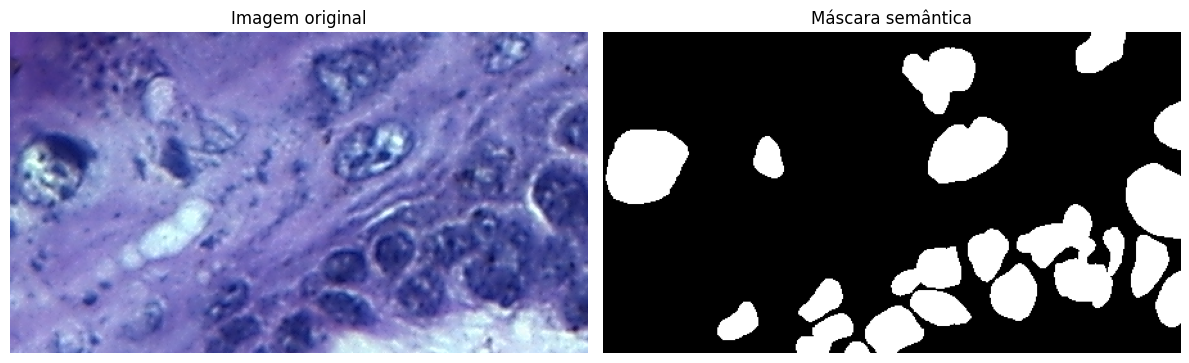

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagem)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mascara, cmap="gray")
plt.title("Máscara semântica")
plt.axis("off")

plt.tight_layout()
plt.show()

Severe

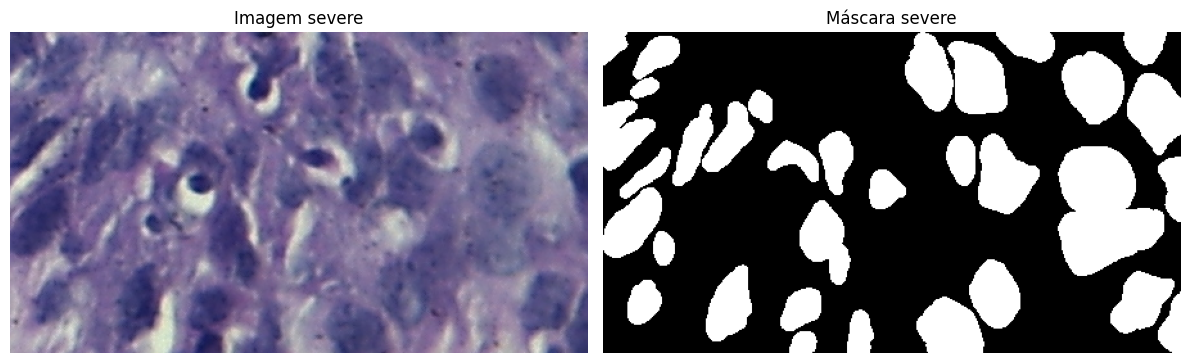

Valores presentes na máscara: [  0 255]


In [27]:
indice = len(healthy_image_paths)

imagem = cv2.imread(image_paths[indice])
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

mascara = cv2.imread(mask_paths[indice], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagem)
plt.title("Imagem severe")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mascara, cmap="gray")
plt.title("Máscara severe")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Valores presentes na máscara:", np.unique(mascara))

**Etapa 2 — Fixar a seed e verificar a GPU**

In [28]:
import random
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import torchvision.transforms.functional as TF

In [29]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo utilizado:", device)

Dispositivo utilizado: cuda


**Etapa 3 — Garantir que os pares estão corretos**

In [30]:
def obter_identificador(caminho):
    nome = os.path.basename(caminho)
    return os.path.splitext(nome)[0]

pares_incorretos = []

for image_path, mask_path in zip(image_paths, mask_paths):
    id_imagem = obter_identificador(image_path)
    id_mascara = obter_identificador(mask_path)

    if id_imagem != id_mascara:
        pares_incorretos.append((id_imagem, id_mascara))

print(f"Total de imagens: {len(image_paths)}")
print(f"Total de máscaras: {len(mask_paths)}")
print(f"Pares incorretos: {len(pares_incorretos)}")

if pares_incorretos:
    print(pares_incorretos[:10])
else:
    print("Todas as imagens possuem a máscara correspondente.")

Total de imagens: 228
Total de máscaras: 228
Pares incorretos: 0
Todas as imagens possuem a máscara correspondente.


**Etapa 4 — Dividir em treino, validação e teste**

In [31]:
labels = (
    ["healthy"] * len(healthy_image_paths)
    + ["severe"] * len(severe_image_paths)
)

train_images, temp_images, train_masks, temp_masks, train_labels, temp_labels = train_test_split(
    image_paths,
    mask_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_images, test_images, val_masks, test_masks, val_labels, test_labels = train_test_split(
    temp_images,
    temp_masks,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print(f"Treino   : {len(train_images)} pares")
print(f"Validação: {len(val_images)} pares")
print(f"Teste    : {len(test_images)} pares")

Treino   : 159 pares
Validação: 34 pares
Teste    : 35 pares


In [32]:
from collections import Counter

print("Treino   :", Counter(train_labels))
print("Validação:", Counter(val_labels))
print("Teste    :", Counter(test_labels))

Treino   : Counter({'severe': 80, 'healthy': 79})
Validação: Counter({'severe': 17, 'healthy': 17})
Teste    : Counter({'healthy': 18, 'severe': 17})


**Etapa 5 - Criando Classe Data Set**

In [33]:
class OralEpitheliumDataset(Dataset):

    def __init__(self, image_paths, mask_paths, image_size=(256, 256)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.image_size = image_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        # Abrir a imagem
        image = cv2.imread(self.image_paths[index])

        if image is None:
            raise FileNotFoundError(
                f"Não foi possível abrir a imagem: {self.image_paths[index]}"
            )

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Abrir a máscara em escala de cinza
        mask = cv2.imread(
            self.mask_paths[index],
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            raise FileNotFoundError(
                f"Não foi possível abrir a máscara: {self.mask_paths[index]}"
            )

        # Redimensionar a imagem
        image = cv2.resize(
            image,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        )

        # Redimensionar a máscara sem criar valores intermediários
        mask = cv2.resize(
            mask,
            self.image_size,
            interpolation=cv2.INTER_NEAREST
        )

        # Converter a máscara para 0 = fundo e 1 = núcleo
        mask = (mask > 0).astype(np.int64)

        # Converter imagem de HWC para CHW
        image = image.transpose(2, 0, 1)

        # Converter para tensor e normalizar para o intervalo [0, 1]
        image = torch.tensor(image, dtype=torch.float32) / 255.0

        # Normalização usada nos modelos pré-treinados no ImageNet
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        image = (image - mean) / std

        # A CrossEntropyLoss exige máscara do tipo long
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [34]:
train_dataset = OralEpitheliumDataset(
    train_images,
    train_masks
)

val_dataset = OralEpitheliumDataset(
    val_images,
    val_masks
)

test_dataset = OralEpitheliumDataset(
    test_images,
    test_masks
)

print(f"Treino   : {len(train_dataset)} exemplos")
print(f"Validação: {len(val_dataset)} exemplos")
print(f"Teste    : {len(test_dataset)} exemplos")

Treino   : 159 exemplos
Validação: 34 exemplos
Teste    : 35 exemplos


Criação dos DataLoaders

In [36]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders criados com sucesso.")

DataLoaders criados com sucesso.


In [37]:
#Teste batch
images_batch, masks_batch = next(iter(train_loader))

print("Formato do batch de imagens :", images_batch.shape)
print("Formato do batch de máscaras:", masks_batch.shape)

print("Tipo das imagens :", images_batch.dtype)
print("Tipo das máscaras:", masks_batch.dtype)

print("Valores presentes nas máscaras:", torch.unique(masks_batch))

Formato do batch de imagens : torch.Size([4, 3, 256, 256])
Formato do batch de máscaras: torch.Size([4, 256, 256])
Tipo das imagens : torch.float32
Tipo das máscaras: torch.int64
Valores presentes nas máscaras: tensor([0, 1])


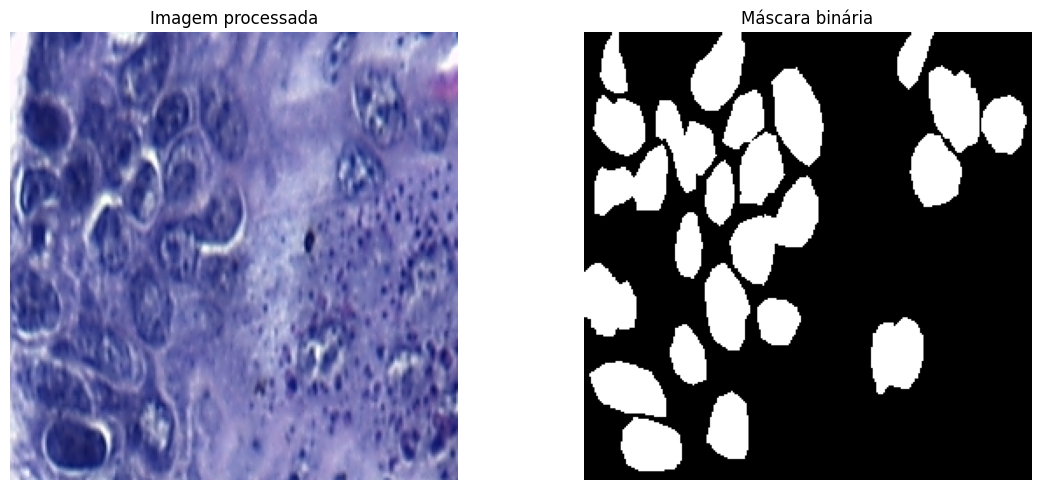

Valores da máscara: [0 1]


In [38]:
image_tensor, mask_tensor = train_dataset[0]

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

image_visual = image_tensor * std + mean
image_visual = image_visual.clamp(0, 1)
image_visual = image_visual.permute(1, 2, 0).numpy()

mask_visual = mask_tensor.numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_visual)
plt.title("Imagem processada")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_visual, cmap="gray")
plt.title("Máscara binária")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Valores da máscara:", np.unique(mask_visual))

**Etapa 6 — Criar a FCN**

In [39]:
from torchvision.models.segmentation import (
    fcn_resnet50,
    FCN_ResNet50_Weights
)

In [40]:
weights = FCN_ResNet50_Weights.DEFAULT

model = fcn_resnet50(
    weights=weights
)

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:00<00:00, 191MB/s]


A FCN original foi treinada para várias classes. Precisamos substituir a última camada para gerar apenas duas saídas.

In [41]:
model.classifier[4] = nn.Conv2d(
    in_channels=512,
    out_channels=2,
    kernel_size=1
)

In [42]:
if model.aux_classifier is not None:
    model.aux_classifier[4] = nn.Conv2d(
        in_channels=256,
        out_channels=2,
        kernel_size=1
    )

In [43]:
model = model.to(device)

print("Modelo criado com sucesso.")
print("Dispositivo:", device)

Modelo criado com sucesso.
Dispositivo: cuda


**Etapa 7 — Testar a saída da rede**

In [44]:
model.eval()

with torch.no_grad():

    images_test = images_batch.to(device)

    outputs = model(images_test)

    predictions = outputs["out"]

In [45]:
print("Formato das imagens:", images_test.shape)
print("Formato da saída  :", predictions.shape)
print("Chaves retornadas :", outputs.keys())

Formato das imagens: torch.Size([4, 3, 256, 256])
Formato da saída  : torch.Size([4, 2, 256, 256])
Chaves retornadas : odict_keys(['out', 'aux'])


Converter a saída em máscara prevista

In [46]:
predicted_masks = torch.argmax(
    predictions,
    dim=1
)

print("Formato das máscaras previstas:", predicted_masks.shape)
print(
    "Valores presentes nas previsões:",
    torch.unique(predicted_masks)
)

Formato das máscaras previstas: torch.Size([4, 256, 256])
Valores presentes nas previsões: tensor([0, 1], device='cuda:0')


Liberar memória do teste

In [47]:
del images_test
del outputs
del predictions
del predicted_masks

if torch.cuda.is_available():
    torch.cuda.empty_cache()